Mounting Google Drive...
Notice: Running in standard/local environment or Drive already accessible.
Dataset not found at default paths. Please upload 'seasonal_agriculture_performance_dataset (2).csv':


Saving seasonal_agriculture_performance_dataset (2).csv to seasonal_agriculture_performance_dataset (2).csv
Loading dataset from: seasonal_agriculture_performance_dataset (2).csv

DATA AUDIT & PREPROCESSING
Raw shape: 4000 rows, 28 columns
Missing values per column before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after preprocessing: 0
Cleaned dataset shape: (4000, 32)

SEASONAL AGGREGATION & PERFORMANCE BENCHMARK


,Record_Count,Avg_Yield_t_ha,Avg_Rainfall_mm,Avg_Temp_C,Avg_Profit_Ha_INR,Avg_Water_Eff,Avg_Pest_Risk_pct
Season,,,,,,,
Kharif,1779,5.63,852.10,28.45,21881.81,5.89,54.47
Rabi,1627,5.09,435.95,23.49,10361.68,5.19,40.48
Zaid,594,4.64,299.16,31.04,-2636.52,4.41,38.22


/tmp/ipykernel_1997/1168766954.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2', showmeans=True,


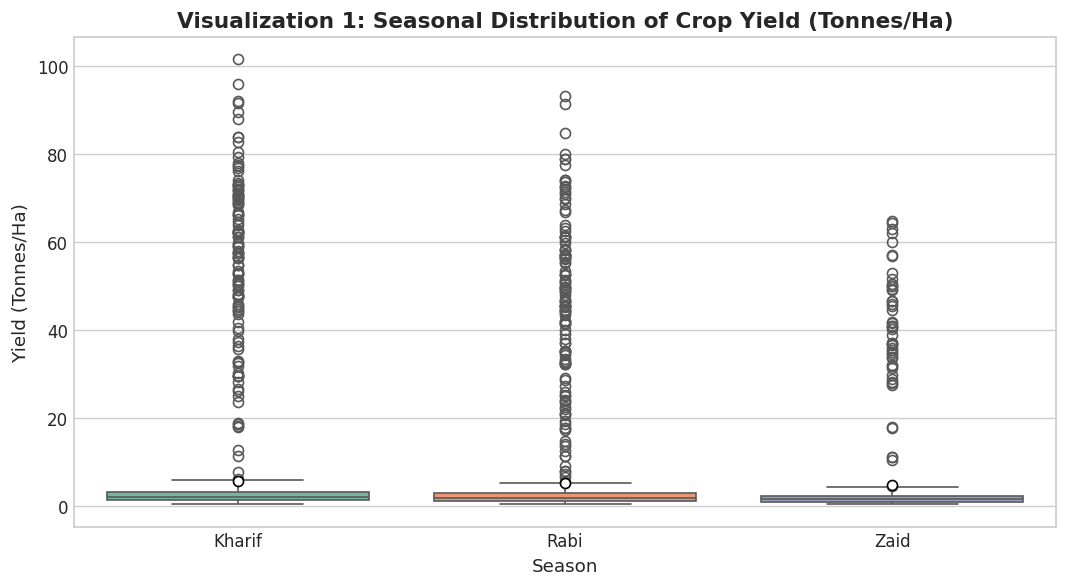

/tmp/ipykernel_1997/1168766954.py:116: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=melted_env, x='Parameter', y='Observed_Value', hue='Season', ci=None, palette='Blues_d')


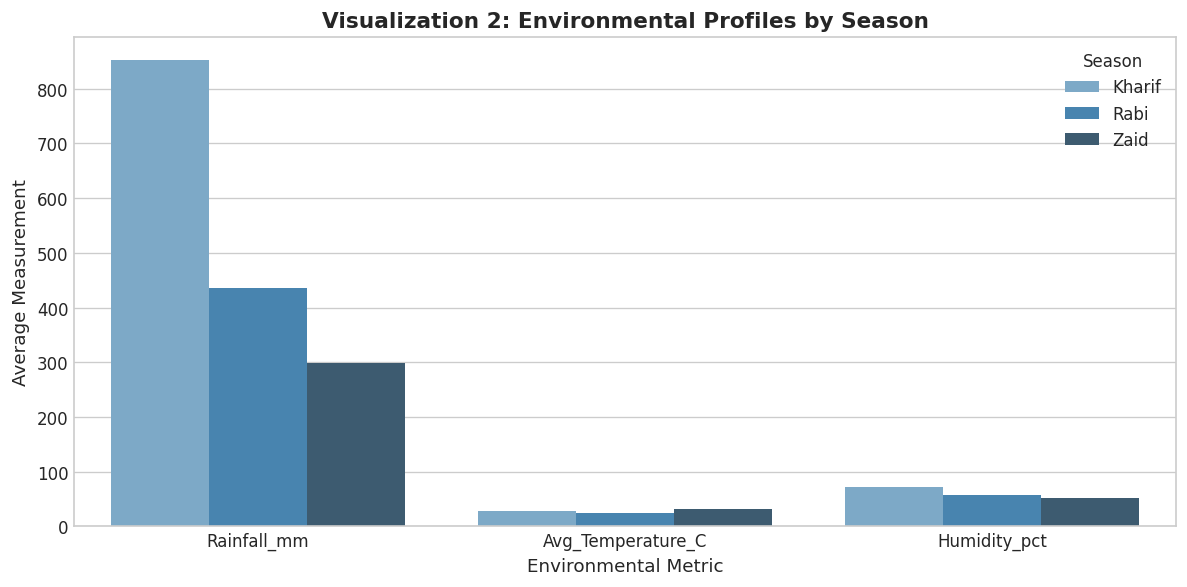

/tmp/ipykernel_1997/1168766954.py:126: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='Accent', ci=None)


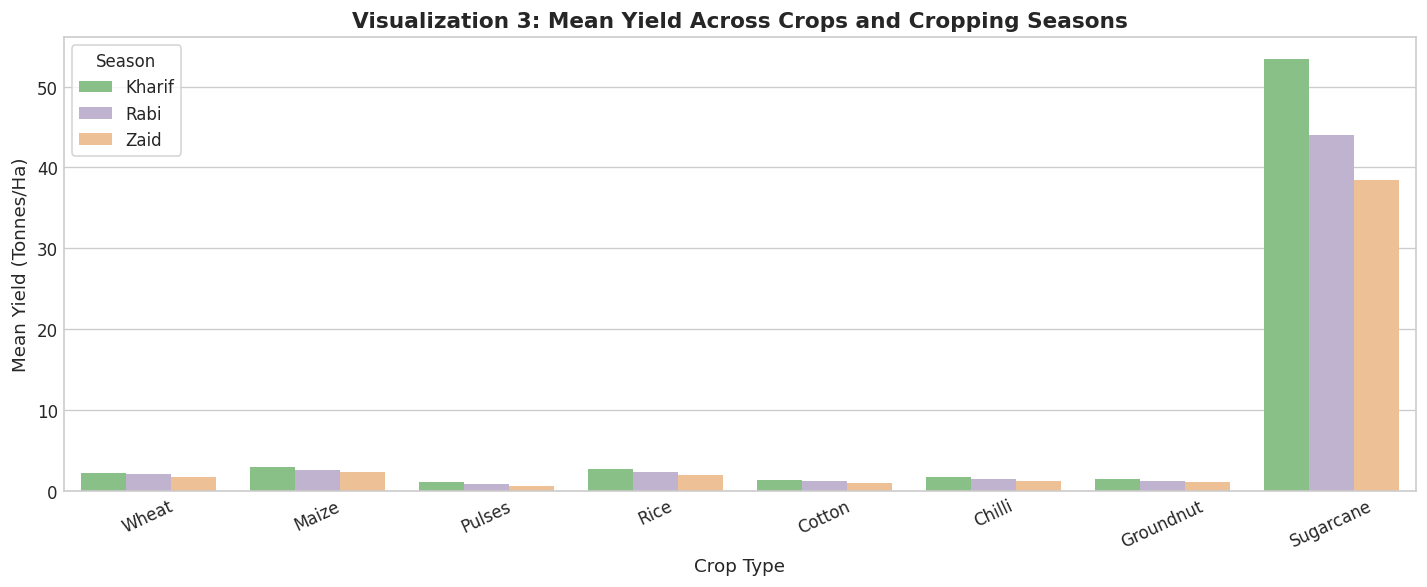

/tmp/ipykernel_1997/1168766954.py:138: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='mako', ci=None)


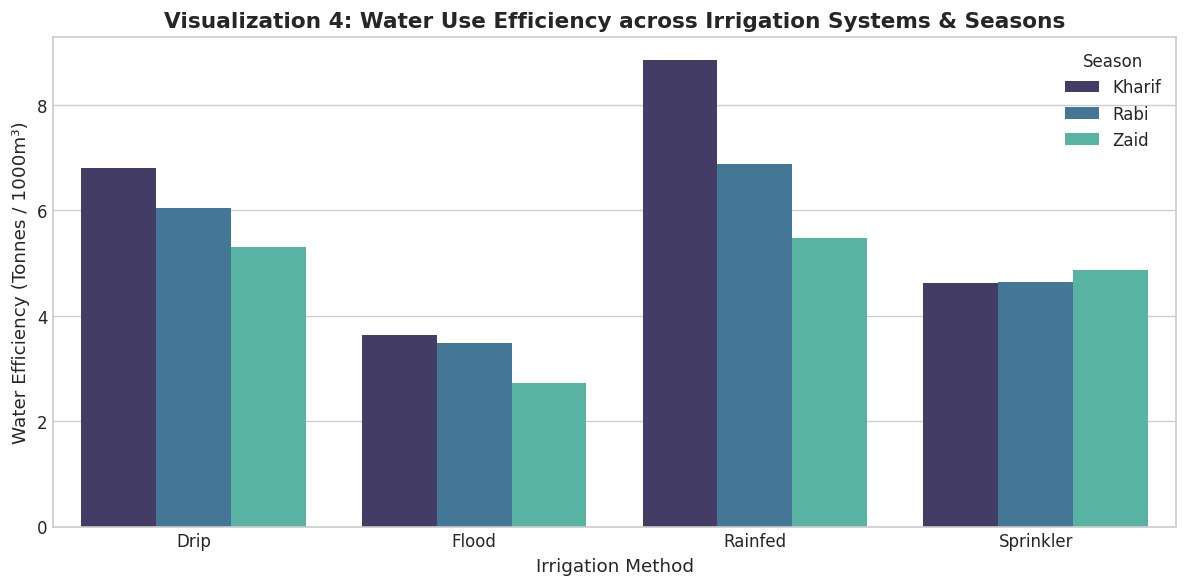

/tmp/ipykernel_1997/1168766954.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Profit_Per_Hectare_INR', palette='Purples', inner='quartile')


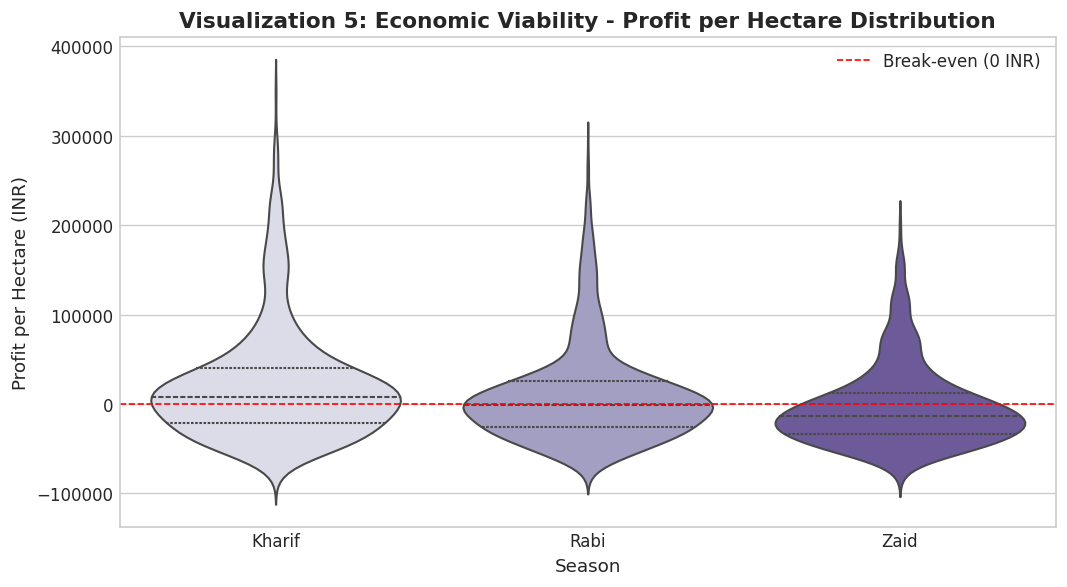

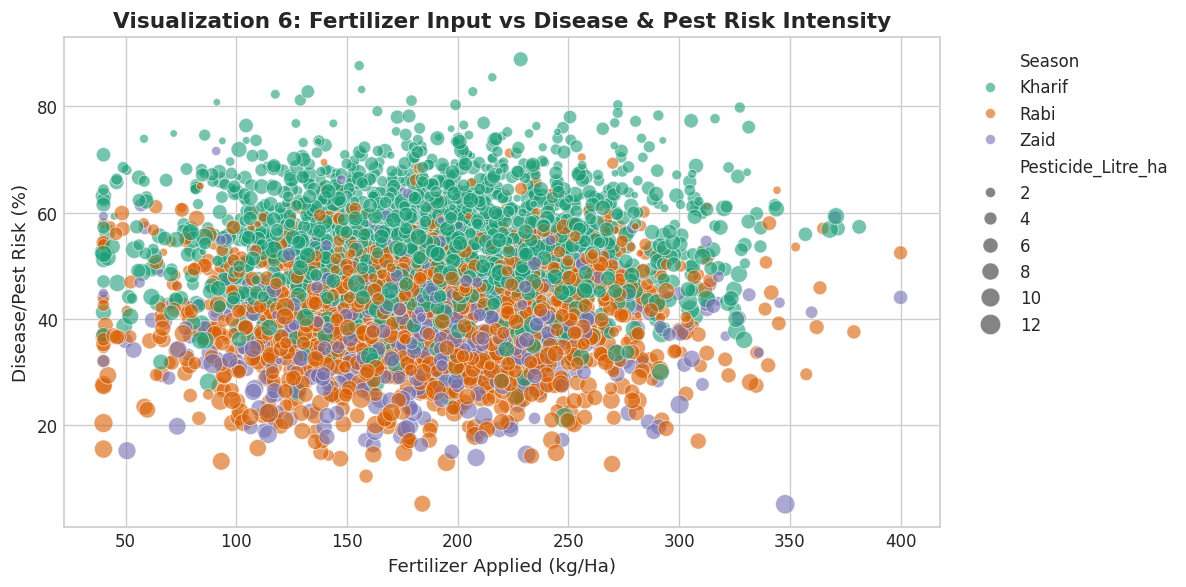

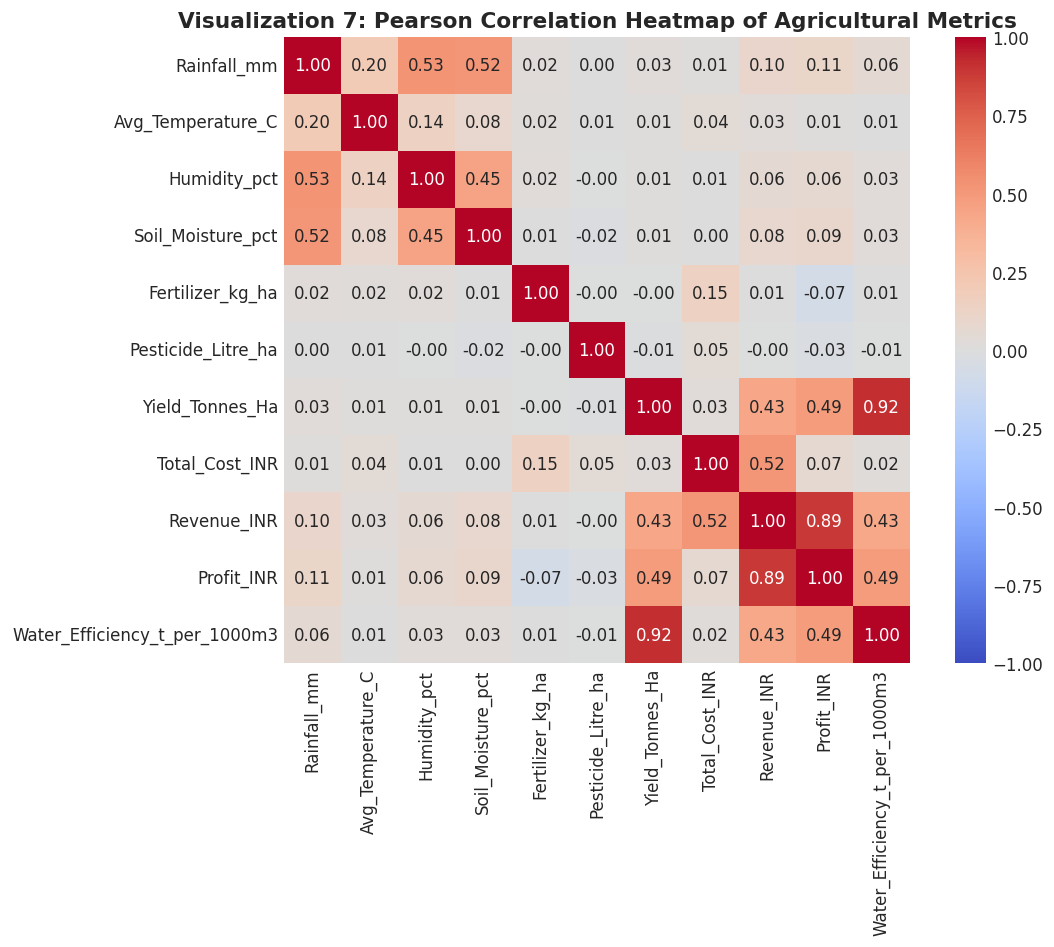

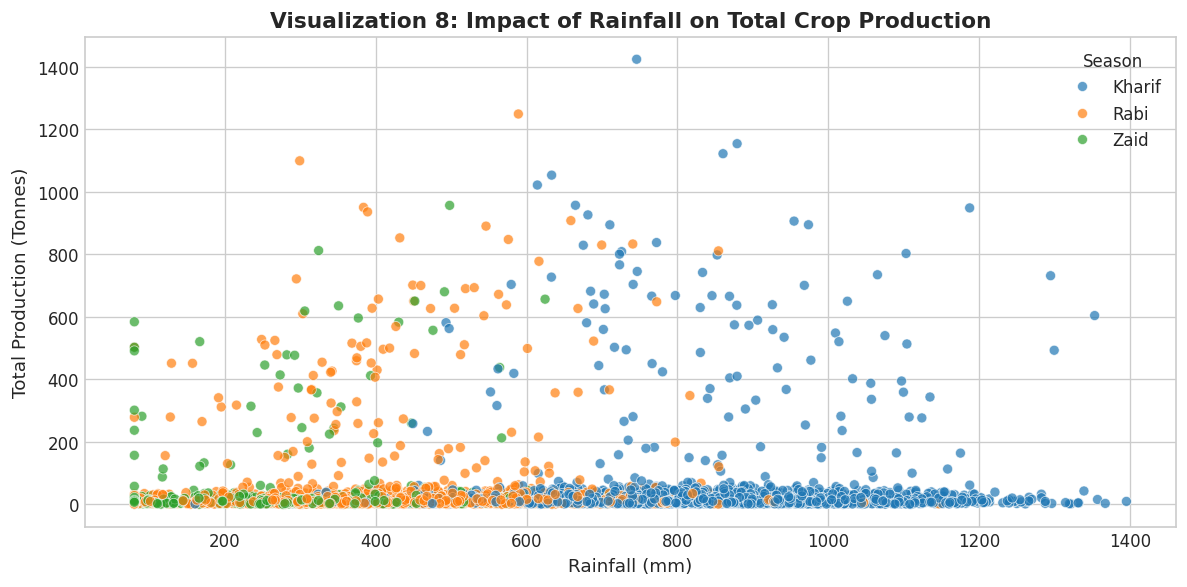

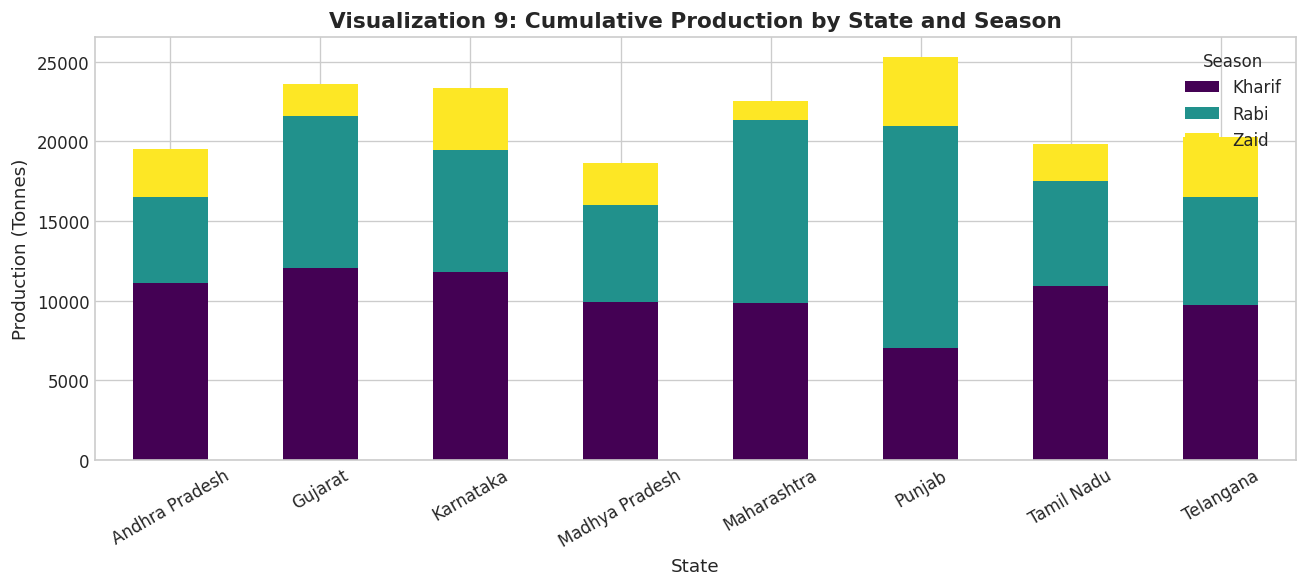

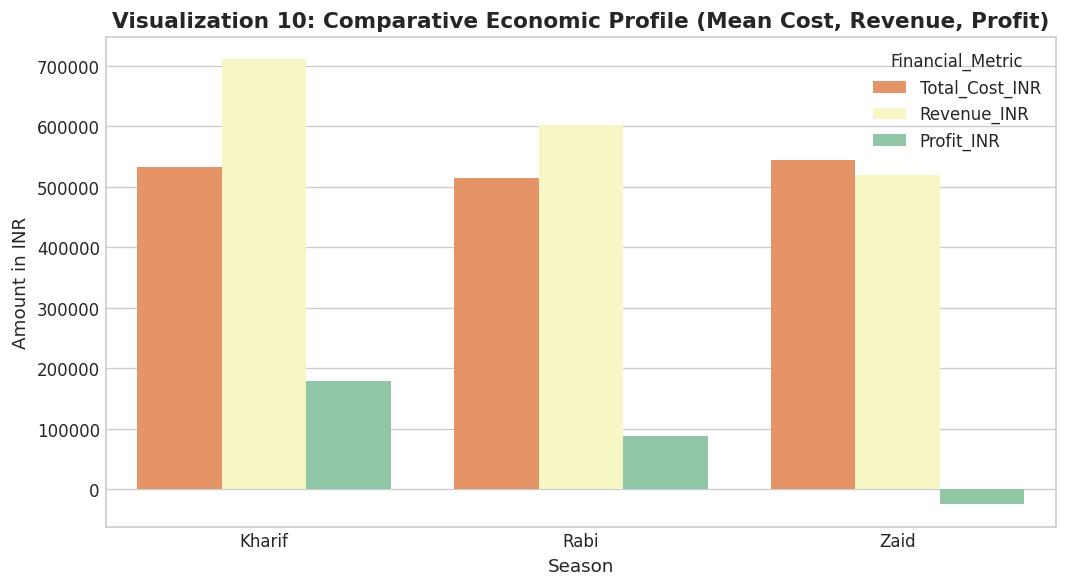


STATISTICAL VALIDATION (ONE-WAY ANOVA ACROSS SEASONS)
Yield_Tonnes_Ha                | F-Statistic:    1.458 | p-value: 2.3285e-01 | Not Significant (p >= 0.05)
Profit_Per_Hectare_INR         | F-Statistic:   43.460 | p-value: 2.1274e-19 | Statistically Significant (p < 0.05)
Water_Efficiency_t_per_1000m3  | F-Statistic:    6.948 | p-value: 9.7194e-04 | Statistically Significant (p < 0.05)
Disease_Pest_Risk_pct          | F-Statistic: 1049.467 | p-value: 0.0000e+00 | Statistically Significant (p < 0.05)

Analysis complete. All 10 plots saved in folder: /content/project_visualizations


In [1]:
# ==============================================================================
# VOIS AICTE MAJOR PROJECT: SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# Platform: Google Colab / Google Drive
# ==============================================================================

# --- CELL 1: Environment Setup & Drive Mounting ---
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
sns.set_palette('tab10')

# Attempt Google Drive Mount (Colab Specific)
DATA_PATH = 'seasonal_agriculture_performance_dataset (2).csv'

try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive', force_remount=False)

    # Common Drive directory search paths
    candidate_paths = [
        '/content/seasonal_agriculture_performance_dataset (2).csv',
        '/content/drive/MyDrive/seasonal_agriculture_performance_dataset (2).csv',
        '/content/drive/MyDrive/Agricultural_Project/seasonal_agriculture_performance_dataset (2).csv'
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            DATA_PATH = path
            break
except Exception as e:
    print("Notice: Running in standard/local environment or Drive already accessible.")

# Fallback: File upload prompt if file not found
if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Dataset not found at default paths. Please upload 'seasonal_agriculture_performance_dataset (2).csv':")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname.endswith('.csv'):
                DATA_PATH = fname
                break
    except Exception:
        pass

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
output_dir = './project_visualizations'
os.makedirs(output_dir, exist_ok=True)

# --- CELL 2: Data Cleaning & Preprocessing ---
print("\n" + "="*60)
print("DATA AUDIT & PREPROCESSING")
print("="*60)
print(f"Raw shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Missing values per column before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values using seasonal median strategy
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    if col in df.columns and df[col].isnull().any():
        df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))
        # Fallback if any remain
        df[col] = df[col].fillna(df[col].median())

# Derived economic & operational metrics
df['Profit_Per_Hectare_INR'] = df['Profit_INR'] / df['Farm_Area_Hectares']
df['Cost_Per_Hectare_INR'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_Per_Hectare_INR'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
df['NPK_Total_kg_ha'] = df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']

print("\nMissing values after preprocessing:", df.isnull().sum().sum())
print(f"Cleaned dataset shape: {df.shape}")

# --- CELL 3: Summary Statistics & Seasonal Profiling ---
print("\n" + "="*60)
print("SEASONAL AGGREGATION & PERFORMANCE BENCHMARK")
print("="*60)
seasonal_summary = df.groupby('Season').agg(
    Record_Count=('Farm_ID', 'count'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Avg_Profit_Ha_INR=('Profit_Per_Hectare_INR', 'mean'),
    Avg_Water_Eff=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Pest_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)
display(seasonal_summary)

# --- CELL 4: Visualizations 1 to 10 ---

# 1. Seasonal Crop Yield Distribution
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Visualization 1: Seasonal Distribution of Crop Yield (Tonnes/Ha)', fontsize=13, fontweight='bold')
plt.xlabel('Season', fontsize=11)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_1_seasonal_yield.png', dpi=150)
plt.show()

# 2. Environmental Dynamics Across Seasons
plt.figure(figsize=(10, 5))
melted_env = df.melt(id_vars=['Season'], value_vars=['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct'],
                     var_name='Parameter', value_name='Observed_Value')
sns.barplot(data=melted_env, x='Parameter', y='Observed_Value', hue='Season', ci=None, palette='Blues_d')
plt.title('Visualization 2: Environmental Profiles by Season', fontsize=13, fontweight='bold')
plt.xlabel('Environmental Metric', fontsize=11)
plt.ylabel('Average Measurement', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_2_environmental_comparison.png', dpi=150)
plt.show()

# 3. Crop-wise Yield Comparison Across Seasons
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='Accent', ci=None)
plt.title('Visualization 3: Mean Yield Across Crops and Cropping Seasons', fontsize=13, fontweight='bold')
plt.xlabel('Crop Type', fontsize=11)
plt.ylabel('Mean Yield (Tonnes/Ha)', fontsize=11)
plt.legend(title='Season', frameon=True)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_3_crop_seasonal_yield.png', dpi=150)
plt.show()

# 4. Irrigation Method vs Water Efficiency
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='mako', ci=None)
plt.title('Visualization 4: Water Use Efficiency across Irrigation Systems & Seasons', fontsize=13, fontweight='bold')
plt.xlabel('Irrigation Method', fontsize=11)
plt.ylabel('Water Efficiency (Tonnes / 1000m³)', fontsize=11)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_4_irrigation_efficiency.png', dpi=150)
plt.show()

# 5. Economic Performance: Net Profit per Hectare
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Season', y='Profit_Per_Hectare_INR', palette='Purples', inner='quartile')
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even (0 INR)')
plt.title('Visualization 5: Economic Viability - Profit per Hectare Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Season', fontsize=11)
plt.ylabel('Profit per Hectare (INR)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_5_profit_distribution.png', dpi=150)
plt.show()

# 6. Agrochemical Usage vs Disease/Pest Risk
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Disease_Pest_Risk_pct', hue='Season',
                size='Pesticide_Litre_ha', sizes=(20, 150), alpha=0.6, palette='Dark2')
plt.title('Visualization 6: Fertilizer Input vs Disease & Pest Risk Intensity', fontsize=13, fontweight='bold')
plt.xlabel('Fertilizer Applied (kg/Ha)', fontsize=11)
plt.ylabel('Disease/Pest Risk (%)', fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_6_pest_risk_vs_inputs.png', dpi=150)
plt.show()

# 7. Correlation Heatmap of Agronomic and Economic Factors
plt.figure(figsize=(10, 8))
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Yield_Tonnes_Ha',
             'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Efficiency_t_per_1000m3']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Visualization 7: Pearson Correlation Heatmap of Agricultural Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_7_correlation_matrix.png', dpi=150)
plt.show()

# 8. Rainfall vs Crop Production by Season
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Production_Tonnes', hue='Season', alpha=0.7, palette='tab10')
plt.title('Visualization 8: Impact of Rainfall on Total Crop Production', fontsize=13, fontweight='bold')
plt.xlabel('Rainfall (mm)', fontsize=11)
plt.ylabel('Total Production (Tonnes)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_8_rainfall_vs_production.png', dpi=150)
plt.show()

# 9. State-Wise Total Production Output
plt.figure(figsize=(11, 5))
state_prod = df.groupby(['State', 'Season'])['Production_Tonnes'].sum().unstack().fillna(0)
state_prod.plot(kind='bar', stacked=True, colormap='viridis', figsize=(11, 5), ax=plt.gca())
plt.title('Visualization 9: Cumulative Production by State and Season', fontsize=13, fontweight='bold')
plt.xlabel('State', fontsize=11)
plt.ylabel('Production (Tonnes)', fontsize=11)
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_9_state_production.png', dpi=150)
plt.show()

# 10. Cost Breakdown vs Revenue Across Cropping Seasons
plt.figure(figsize=(9, 5))
econ_df = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean().reset_index()
econ_melt = econ_df.melt(id_vars='Season', value_vars=['Total_Cost_INR', 'Revenue_INR', 'Profit_INR'],
                         var_name='Financial_Metric', value_name='Amount_INR')
sns.barplot(data=econ_melt, x='Season', y='Amount_INR', hue='Financial_Metric', palette='Spectral')
plt.title('Visualization 10: Comparative Economic Profile (Mean Cost, Revenue, Profit)', fontsize=13, fontweight='bold')
plt.xlabel('Season', fontsize=11)
plt.ylabel('Amount in INR', fontsize=11)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig(f'{output_dir}/vis_10_financial_profile.png', dpi=150)
plt.show()

# --- CELL 5: Statistical Hypothesis Testing (ANOVA) ---
print("\n" + "="*60)
print("STATISTICAL VALIDATION (ONE-WAY ANOVA ACROSS SEASONS)")
print("="*60)

for metric in ['Yield_Tonnes_Ha', 'Profit_Per_Hectare_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']:
    groups = [group[metric].dropna().values for _, group in df.groupby('Season')]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = "Statistically Significant (p < 0.05)" if p_val < 0.05 else "Not Significant (p >= 0.05)"
    print(f"{metric:<30} | F-Statistic: {f_stat:8.3f} | p-value: {p_val:.4e} | {sig}")

print("\nAnalysis complete. All 10 plots saved in folder:", os.path.abspath(output_dir))